In [1]:
pip install pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data
df = pd.read_csv("Data/raw_analyst_ratings.csv")

Descriptive Statistics
1 Headline Length Analysis

In [5]:
df['headline_length'] = df['headline'].astype(str).apply(len)

df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

Visualize headline length distribution

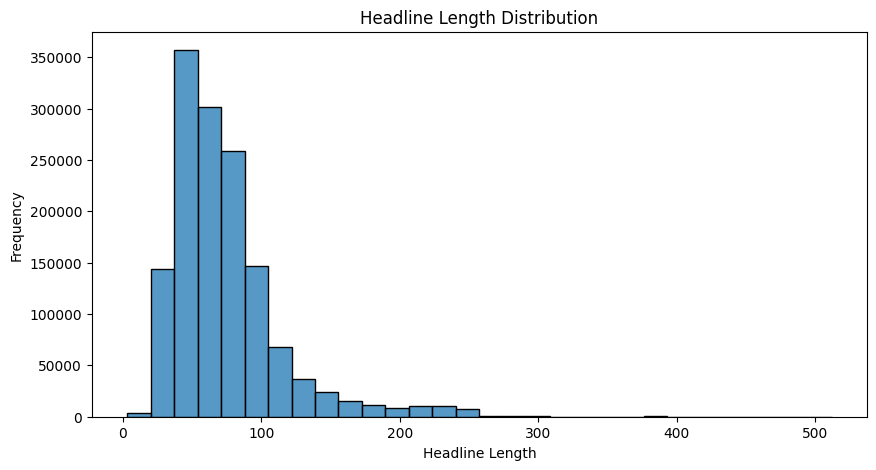

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['headline_length'], bins=30)
plt.title('Headline Length Distribution')
plt.xlabel('Headline Length')
plt.ylabel('Frequency')
plt.show()

Count Articles Per Publisher

In [7]:
publisher_counts = df['publisher'].value_counts()

publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

Visualize top publishers

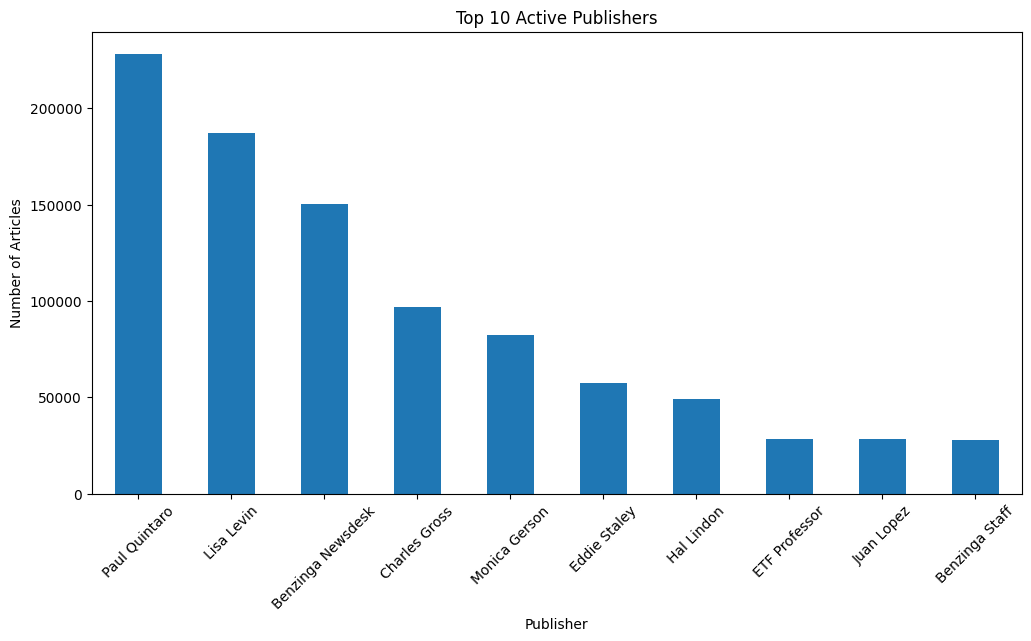

In [8]:
top_publishers = publisher_counts.head(10)

plt.figure(figsize=(12,6))
top_publishers.plot(kind='bar')
plt.title('Top 10 Active Publishers')
plt.xlabel('Publisher')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()

Publication Trends Over Time

In [10]:
from datetime import datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

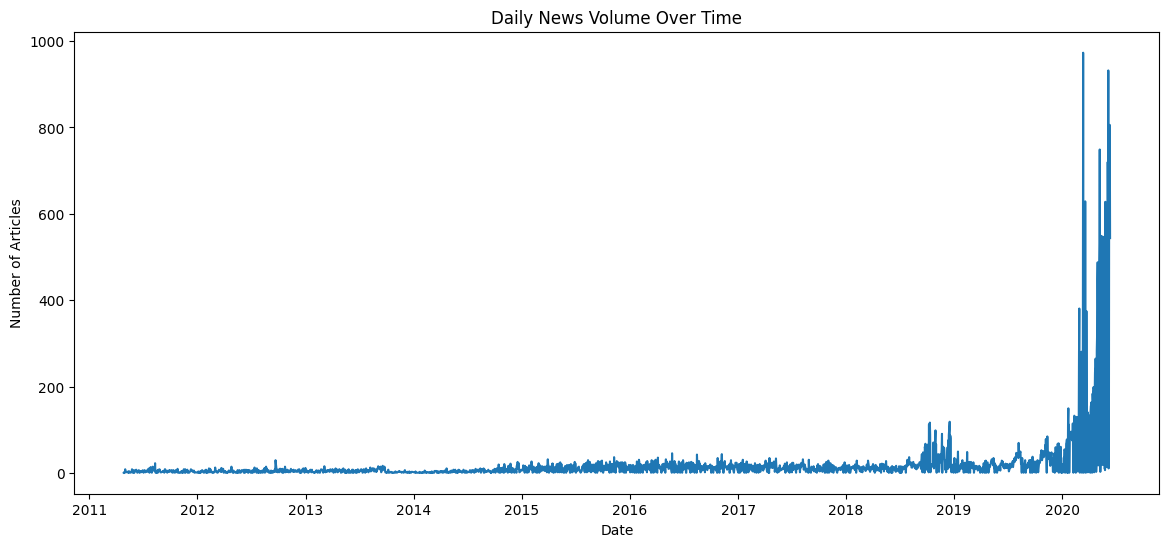

In [11]:
df['publication_day'] = df['date'].dt.date    
daily_news = df.groupby('publication_day').size()
plt.figure(figsize=(14,6))
daily_news.plot()
plt.title('Daily News Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.show()

5. Text Analysis (Topic Modeling)
5.1 Common Keywords Using CountVectorizer

In [13]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [14]:
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(df['headline'].astype(str))

word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
})

word_counts = word_counts.sort_values(by='count', ascending=False)

word_counts

,word,count
18,vs,162099
15,stocks,161776
6,est,140604
5,eps,128897
7,market,120558
14,shares,114313
12,reports,108710
17,update,91723
4,earnings,87399
13,sales,79645


6. Time Series Analysis of News Volume
6.1 News Frequency Over Time

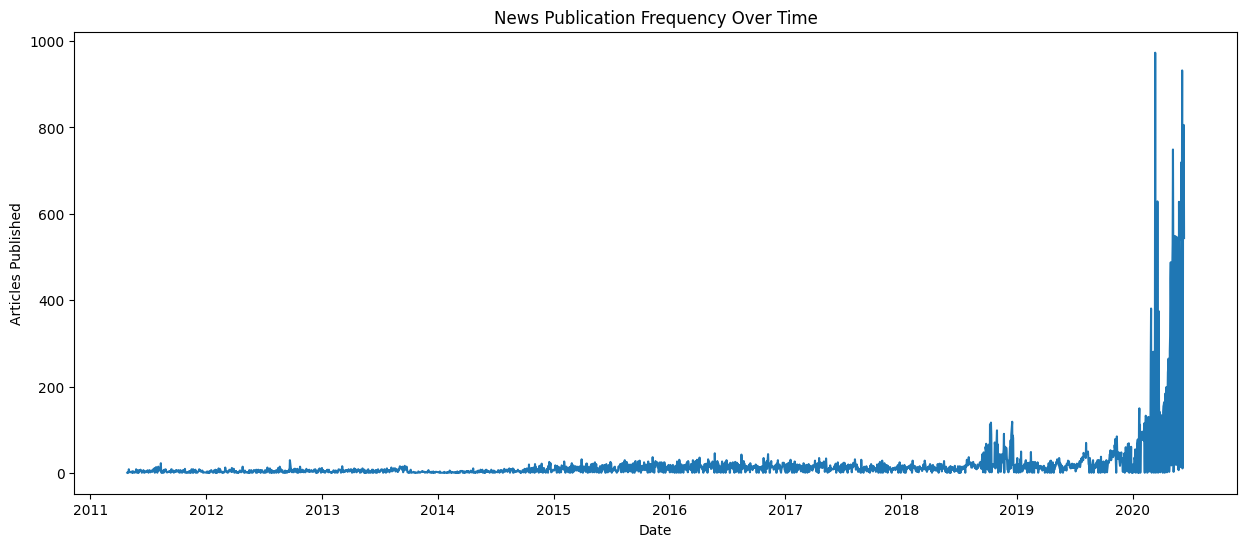

In [15]:
news_per_day = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(15,6))
news_per_day.plot()
plt.title('News Publication Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Articles Published')
plt.show()

6.2 Identify Spikes

In [16]:
top_spikes = news_per_day.sort_values(ascending=False).head(10)

top_spikes

date
2020-03-12    973
2020-06-05    932
2020-06-10    806
2020-06-09    804
2020-06-08    765
2020-05-07    749
2020-06-03    720
2020-03-19    629
2020-05-26    628
2020-05-13    549
dtype: int64

You can discuss possible reasons:
earnings season
mergers
FDA announcements
economic reports
This satisfies:
✔ Identify spikes and relate them to events

6.3 Analyze Publishing Hours

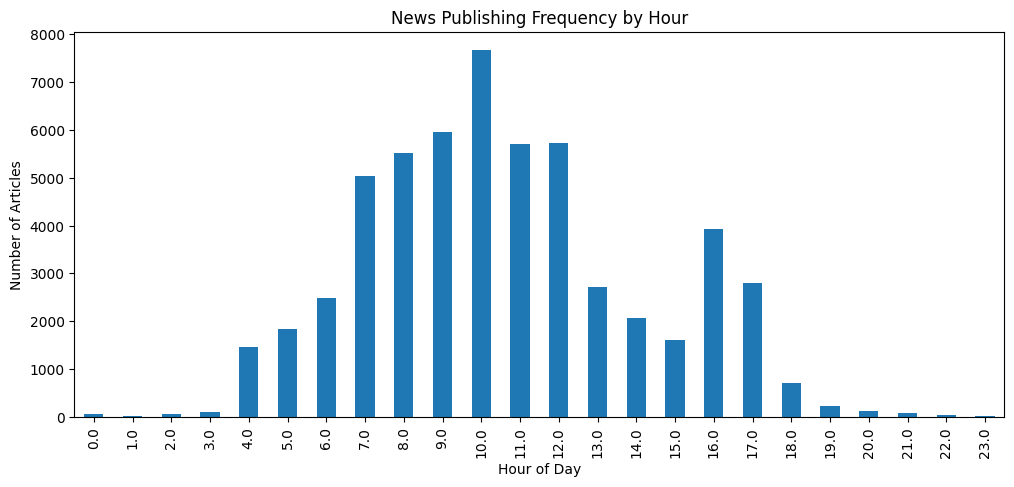

In [17]:
df['hour'] = df['date'].dt.hour
hourly_news = df.groupby('hour').size()
plt.figure(figsize=(12,5))
hourly_news.plot(kind='bar')
plt.title('News Publishing Frequency by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Articles')
plt.show()

7.Publisher Analysis
7.1 Most Active Publishers

In [18]:
top_publishers = df['publisher'].value_counts().head(20)

top_publishers

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

7.2 Extract Email Domains
Some publishers may appear as emails.
Extract domains.

In [19]:
df['publisher_domain'] = df['publisher'].astype(str).str.extract(r'@([\w\.-]+)')
domain_counts = df['publisher_domain'].value_counts()

domain_counts.head(10)

publisher_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

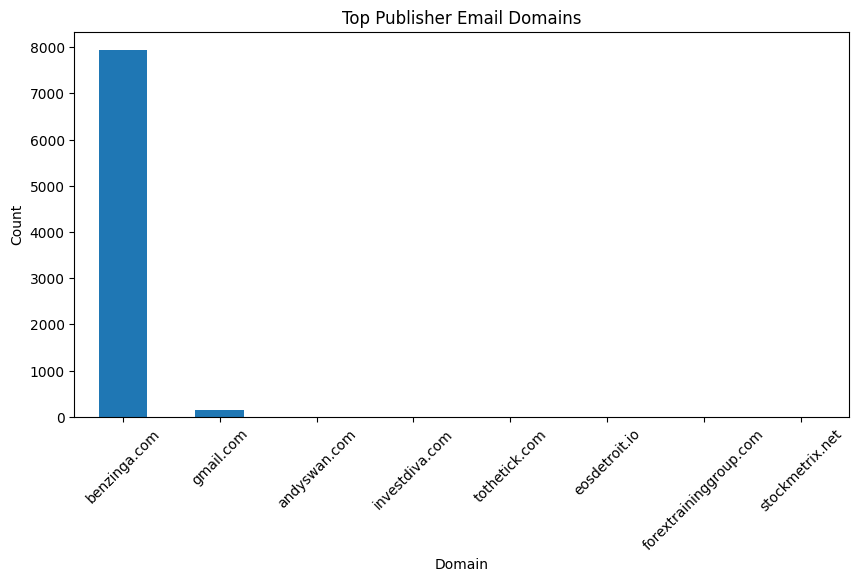

In [20]:
plt.figure(figsize=(10,5))
domain_counts.head(10).plot(kind='bar')
plt.title('Top Publisher Email Domains')
plt.xlabel('Domain')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

8. Final Insights / Conclusions
End the notebook with observations such as:
Most headlines focus on earnings and stock ratings
Certain publishers dominate financial reporting
News volume spikes during major market events
Most articles are released during trading hours
Topic modeling reveals recurring financial themes